In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

df = pd.read_csv("student-mat.csv", sep=";")   # semicolon-separated
print(df.shape, df.isna().sum().sum())          # expect (395, 33) and 0 missing

(395, 33) 0


In [2]:
num_cols = ["age", "studytime", "failures", "absences", "G1", "G2", "G3"]
df[num_cols].agg(["mean", "median", "std"]).round(2)

,age,studytime,failures,absences,G1,G2,G3
mean,16.70,2.04,0.33,5.71,10.91,10.71,10.42
median,17.00,2.00,0.00,4.00,11.00,11.00,11.00
std,1.28,0.84,0.74,8.00,3.32,3.76,4.58


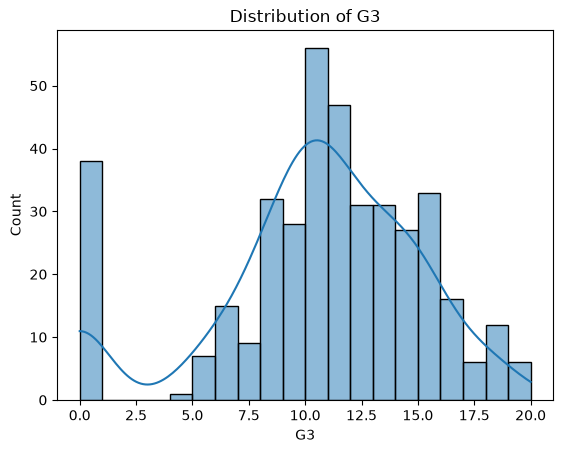

In [3]:
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of G3")
plt.show()

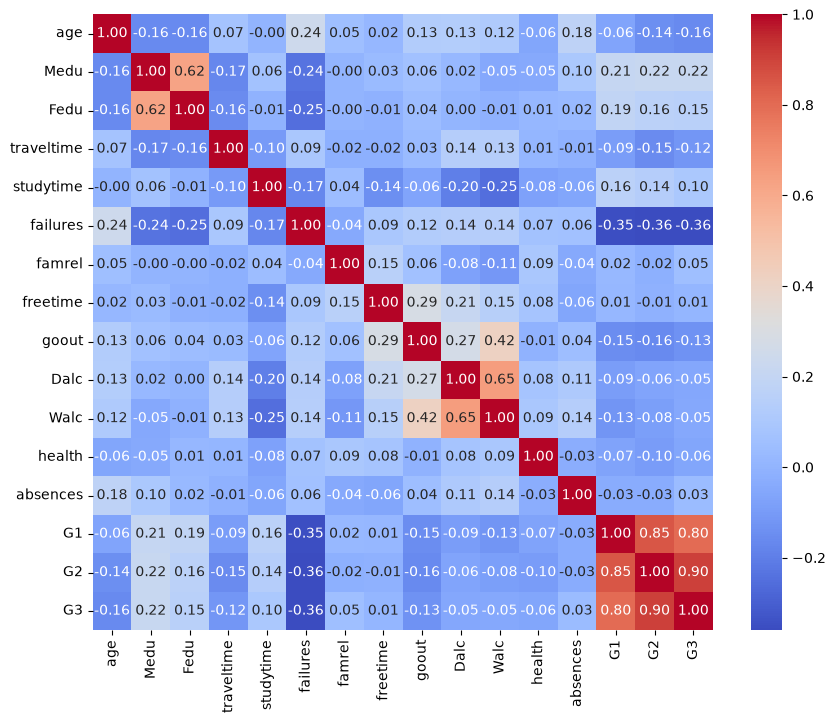

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

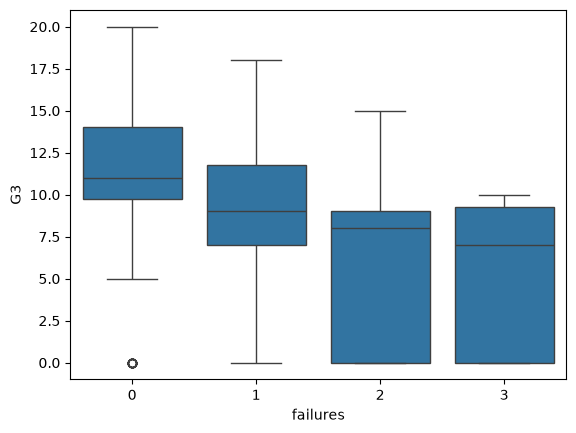

In [5]:
sns.boxplot(x="failures", y="G3", data=df)
plt.show()

I noticed that G3's median is higher than the mean of the data set and there is a distinct cluster of zeros that could represent students who have dropped out or skipped the final exam. G1 and G2 are the strongest correlates of G3 (roughly 0.80 and 0.90), which means if a student scores well in G1 and G2, it is most likely that they will have a good score for G3. Failures has a moderate negative correlation with G3 (about -0.36), and the boxplot shows students with no past failures have a clearly higher median grade than those with one or more. In contrast, studytime is only weakly positive and absences is close to zero, so neither is a strong predictor on its own. absences is also right-skewed (mean above median), since most students miss few classes while a small number miss many.